# SGLN — Infrastructure Performance Dashboard
Ce notebook charge Synthèse DC - Incident.json, applique la logique de catégorisation Nutanix et génère un dashboard exécutif professionnel au format PNG.


In [7]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import patches
from matplotlib.gridspec import GridSpec

plt.rcParams["font.family"] = "Arial"
plt.rcParams["text.color"] = "#003366"
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

BASE_PATH = Path.cwd()

def load_json_to_df(path: Path) -> pd.DataFrame:
    for encoding in ("utf-8", "latin-1"):
        try:
            with open(path, encoding=encoding) as f:
                data = json.load(f)
            return pd.json_normalize(data)
        except Exception:
            continue
    raise ValueError(f"Unable to load JSON file: {path}")

def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    mapping = {}
    for col in df.columns:
        normalized = re.sub(r"[^a-z0-9]", "", str(col).lower())
        if normalized in ("client", "clientname", "tenant", "societe", "company", "entite", "entit"):
            mapping[col] = "Entité"
        elif normalized in ("serveur", "server", "host", "hostname", "apparail"):
            mapping[col] = "Serveur"
        elif normalized in ("titre", "title", "subject", "objet", "description", "summary"):
            mapping[col] = "Titre"
    df = df.rename(columns=mapping)
    for target in ("Entité", "Serveur", "Titre"):
        if target not in df.columns:
            df[target] = pd.NA
    return df

def compute_sla_rate(df: pd.DataFrame) -> float:
    candidate_cols = [
        col for col in df.columns
        if re.sub(r"[^a-z0-9]", "", col.lower())
        in ("sla", "slarespect", "respectsla", "slaconforme")
    ]
    if not candidate_cols:
        return 0.87
    col = candidate_cols[0]
    series = df[col].dropna().astype(str).str.strip()
    if series.empty:
        return 0.87
    mapped = series.str.replace("%", "", regex=False).str.lower()
    mapped = mapped.replace({
        "oui": "1",
        "non": "0",
        "yes": "1",
        "no": "0",
        "y": "1",
        "n": "0",
        "true": "1",
        "false": "0",
    })
    numeric = pd.to_numeric(mapped, errors="coerce").dropna()
    if numeric.empty:
        return 0.87
    if numeric.max() > 1:
        return float(np.clip(numeric.mean() / 100, 0, 1))
    return float(np.clip(numeric.mean(), 0, 1))

def count_critical_alerts(df: pd.DataFrame) -> int:
    candidate_cols = [
        col for col in df.columns
        if re.sub(r"[^a-z0-9]", "", col.lower())
        in ("priorite", "priority", "severity", "criticality")
    ]
    if not candidate_cols:
        return 0
    col = candidate_cols[0]
    series = df[col].dropna().astype(str).str.strip().str.lower()
    numeric = pd.to_numeric(series, errors="coerce")
    mask = pd.Series(False, index=series.index)
    mask |= series.isin(["critique", "critical", "crit", "high", "urgent"])
    mask |= numeric.eq(1)
    return int(mask.sum())

def categorize_row(row: pd.Series) -> str:
    titre = str(row.get("Titre", "") or "")
    serveur = str(row.get("Serveur", "") or "")
    combined = f"{titre} {serveur}"
    if re.search(r"ntnx|nutanix", combined, flags=re.I):
        return "Nutanix"
    if re.search(r"cpu", titre, flags=re.I):
        return "CPU Issue"
    if re.search(r"memory|ram", titre, flags=re.I):
        return "Memory Issue"
    if re.search(r"disk|storage", titre, flags=re.I):
        return "Disk"
    if re.search(r"network|nic|link", titre, flags=re.I):
        return "Network"
    return "OS / Autres"

search_name = "Synthèse DC - Incident.json"
file_path = next(BASE_PATH.rglob(search_name), None)
if file_path is None:
    raise FileNotFoundError(f"Fichier introuvable: {search_name}. Placez-le dans le dossier du notebook.")
print(f"Fichier trouvé : {file_path}")
combined_df = normalize_columns(load_json_to_df(file_path))
combined_df["Entité"] = combined_df["Entité"].fillna("Inconnu").astype(str)
combined_df["Serveur"] = combined_df["Serveur"].fillna("Inconnu").astype(str)
combined_df["Titre"] = combined_df["Titre"].fillna("Sans Titre").astype(str)
combined_df["Categorie"] = combined_df.apply(categorize_row, axis=1)
combined_df.head()


Fichier trouvé : c:\Users\aelazmi2\Desktop\glpi_pipeline.py - TEST 2\Synthèse DC - Incident.json


,ID,Titre,Entité,Statut,Attribué à - Groupe de techniciens,Temps de résolution dépassé,Dernière modification par,Intervention Admin,Date d'ouverture,Date de résolution,time to resolve,Serveur,Problem_Category,Problem_Sub-Category,Categorie
0,25 221,Alerte_Zabbix : [RBAMNT04] High swap space usa...,Data_Center > MINTRA > EMPLOI PUBLIC,Clos,DC-Database_Team,Oui,monito_twin,Non,2025-07-09 18:49:59,2025-07-26 02:13:00,16.307639,RBAMNT04,Memory Issue,High swap space usage,OS / Autres
1,25 610,Alerte_Zabbix : [RBAAVC02] RBAAVC02 Uptime Sta...,Data_Center > CNONM,Clos,DC-Unix_Team,Non,monito_twin,Non,2025-07-15 16:31:59,2025-07-26 02:10:59,10.402083,RBAAVC02,VM availability,Uptime Status > 90 days,OS / Autres
2,25 611,Alerte_Zabbix : [RBAAVC03] RBAAVC03 Uptime Sta...,Data_Center > CNONM,Clos,DC-Unix_Team,Non,monito_twin,Non,2025-07-15 16:31:59,2025-07-26 02:09:00,10.400694,RBAAVC03,VM availability,Uptime Status > 90 days,OS / Autres
3,25 612,Alerte_Zabbix : [RBAAVC01] RBAAVC01 Uptime Sta...,Data_Center > CNONM,Clos,DC-Unix_Team,Non,monito_twin,Non,2025-07-15 16:32:59,2025-07-26 02:09:00,10.400000,RBAAVC01,VM availability,Uptime Status > 90 days,OS / Autres
4,25 613,Alerte_Zabbix : [RBAAVC04] RBAAVC04 Uptime Sta...,Data_Center > CNONM,Clos,DC-Unix_Team,Non,monito_twin,Non,2025-07-15 16:32:59,2025-07-26 02:04:59,10.397222,RBAAVC04,VM availability,Uptime Status > 90 days,OS / Autres


In [10]:
# Calcul des métriques clés
category_order = [
    "CPU Issue",
    "Memory Issue",
    "Disk",
    "Network",
    "Nutanix",
    "OS / Autres",
]
category_counts = combined_df["Categorie"].value_counts().reindex(category_order, fill_value=0)
# Top entities instead of clients
top_entities = combined_df.groupby("Entité").size().sort_values(ascending=False).head(5)
total_tickets = len(combined_df)
sla_rate = compute_sla_rate(combined_df)
sla_percentage = f"{int(round(sla_rate * 100))}%"
critical_alerts = count_critical_alerts(combined_df)
category_counts


Categorie
CPU Issue        2533
Memory Issue     4738
Disk              393
Network             0
Nutanix         13043
OS / Autres      8415
Name: count, dtype: int64

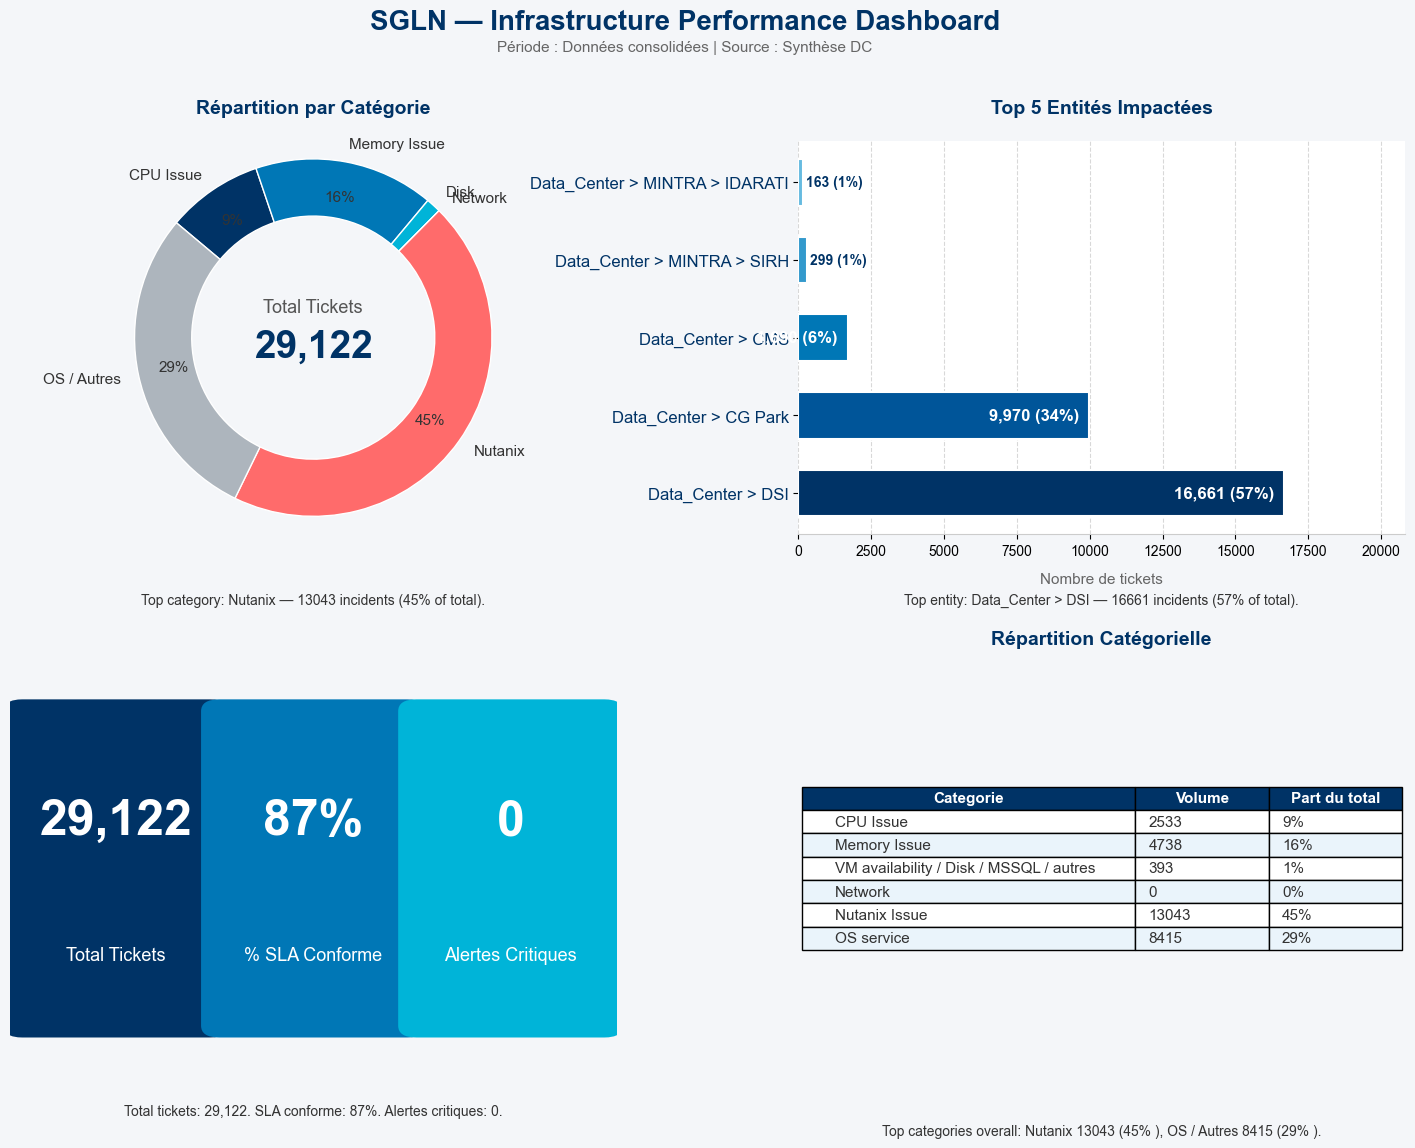

In [12]:
# Création du dashboard 2x2
fig = plt.figure(figsize=(18, 12), facecolor="#F4F6F9")
gs = GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

# Top gauche : Donut chart
ax1 = fig.add_subplot(gs[0, 0])
values = category_counts.values
labels = category_counts.index.tolist()
colors = ["#003366", "#0077B6", "#00B4D8", "#90E0EF", "#FF6B6B", "#ADB5BD"]
wedges, texts, autotexts = ax1.pie(
    values,
    labels=labels,
    colors=colors,
    startangle=140,
    counterclock=False,
    wedgeprops={"width": 0.32, "edgecolor": "white"},
    autopct=lambda pct: "{:.0f}%".format(pct) if pct >= 2 else "",
    pctdistance=0.8,
    textprops={"color": "#333333", "fontsize": 11},
)
centre_circle = plt.Circle((0, 0), 0.55, fc="#F4F6F9", linewidth=0)
ax1.add_artist(centre_circle)
ax1.text(0, -0.05, f"{total_tickets:,}", ha="center", va="center", fontsize=28, fontweight="bold", color="#003366")
ax1.text(0, 0.17, "Total Tickets", ha="center", va="center", fontsize=13, color="#555555")
ax1.set_title("Répartition par Catégorie", pad=20, color="#003366")
ax1.axis("equal")
for spine in ax1.spines.values():
    spine.set_visible(False)
ax1.grid(False)

# Add description under donut chart
top_cat = category_counts.idxmax() if not category_counts.empty else None
if top_cat is not None:
    top_val = int(category_counts.max())
    top_pct = (top_val / total_tickets * 100) if total_tickets>0 else 0
    donut_desc = f"Top category: {top_cat} — {top_val} incidents ({top_pct:.0f}% of total)."
else:
    donut_desc = "No category data available."
ax1.text(0.5, -0.15, donut_desc, ha='center', va='top', fontsize=10, color='#333333', transform=ax1.transAxes)

# Top droite : Top 5 entités - Version améliorée
ax2 = fig.add_subplot(gs[0, 1])
entity_names = top_entities.index.tolist()
entity_values = top_entities.values

# Wrap long entity names for readability
import textwrap
wrap_width = 30
wrapped_names = [textwrap.fill(str(n), wrap_width) for n in entity_names]

# Créer des couleurs dégradées du plus clair au plus foncé
bar_colors = ["#003366", "#005599", "#0077B6", "#3399CC", "#66BBE0"]

# Créer le graphique horizontal
bars = ax2.barh(range(len(wrapped_names)), entity_values[::-1], color=bar_colors[::-1], height=0.6, edgecolor="white", linewidth=1.5)

# Determine thresholds for label placement
max_val = entity_values.max() if len(entity_values)>0 else 0
inside_threshold = max_val * 0.08 if max_val>0 else 1

# Ajouter des étiquettes à l'intérieur/des l'extérieur des barres
for i, (bar, val) in enumerate(zip(bars, entity_values[::-1])):
    pct = (val / total_tickets * 100) if total_tickets>0 else 0
    label_text = f"{int(val):,} ({pct:.0f}%)"
    x = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    if x >= inside_threshold:
        ax2.text(x - (max_val * 0.02 if max_val>0 else 1), y, label_text, va="center", ha="right", color="white", fontsize=12, fontweight="bold")
    else:
        ax2.text(x + (max_val * 0.005 if max_val>0 else 1), y, label_text, va="center", ha="left", color="#003366", fontsize=10, fontweight="bold")

# Personnaliser les axes
ax2.set_yticks(range(len(wrapped_names)))
ax2.set_yticklabels(wrapped_names[::-1], fontsize=12, fontweight="medium", color="#003366")
ax2.set_xlabel("Nombre de tickets", fontsize=11, color="#666666", labelpad=10)
ax2.set_xlim(0, max_val * 1.25 if max_val > 0 else 1)

# Add description under bar chart
if len(entity_names)>0:
    top_entity = entity_names[0]
    top_entity_val = int(entity_values[0])
    top_entity_pct = (top_entity_val / total_tickets * 100) if total_tickets>0 else 0
    bar_desc = f"Top entity: {top_entity} — {top_entity_val} incidents ({top_entity_pct:.0f}% of total)."
else:
    bar_desc = "No entity data available."
ax2.text(0.5, -0.15, bar_desc, ha='center', va='top', fontsize=10, color='#333333', transform=ax2.transAxes)

# Ajouter une grille légère
ax2.xaxis.grid(True, linestyle="--", alpha=0.3, color="gray")
ax2.set_axisbelow(True)

# Supprimer les bordures inutiles
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.spines["left"].set_visible(False)
ax2.spines["bottom"].set_visible(True)
ax2.spines["bottom"].set_color("#CCCCCC")

# Titre
ax2.set_title("Top 5 Entités Impactées", pad=20, color="#003366", fontsize=14, fontweight="bold")

# Inverser l'ordre pour avoir le plus grand en haut
ax2.invert_yaxis()

# Bottom gauche : KPI cards
ax3 = fig.add_subplot(gs[1, 0])
ax3.axis("off")
ax3.set_xlim(0, 1)
ax3.set_ylim(0, 1)
kpi_cards = [
    ("Total Tickets", f"{total_tickets:,}", "#003366"),
    ("% SLA Conforme", sla_percentage, "#0077B6"),
    ("Alertes Critiques", f"{critical_alerts:,}", "#00B4D8"),
]
for idx, (label, value, color) in enumerate(kpi_cards):
    x0 = 0.02 + idx * 0.325
    rect = patches.FancyBboxPatch((x0, 0.1), 0.31, 0.8, boxstyle="round,pad=0.03", facecolor=color, edgecolor="none")
    ax3.add_patch(rect)
    ax3.text(x0 + 0.155, 0.62, value, ha="center", va="center", fontsize=36, fontweight="bold", color="white")
    ax3.text(x0 + 0.155, 0.28, label, ha="center", va="center", fontsize=13, color="white")

# Add description under KPI cards
kpi_desc = f"Total tickets: {total_tickets:,}. SLA conforme: {sla_percentage}. Alertes critiques: {critical_alerts:,}."
ax3.text(0.5, -0.1, kpi_desc, ha='center', va='top', fontsize=10, color='#333333', transform=ax3.transAxes)

# Bottom droite : Table de répartition similaire à votre exemple
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis("off")
display_map = {"OS / Autres": "OS service", "Nutanix": "Nutanix Issue", "Disk": "VM availability / Disk / MSSQL / autres"}
# Ensure table order exactly matches category_order
table_rows = []
for name in category_order:
    display = display_map.get(name, name)
    vol = int(category_counts.get(name, 0))
    pct = int(round((vol / total_tickets * 100), 0)) if total_tickets>0 else 0
    table_rows.append([display, f"{vol}", f"{pct}%"])

table_df = pd.DataFrame(table_rows, columns=["Categorie", "Volume", "Part du total"])

# Draw table with clearer styling
table = ax4.table(
    cellText=table_df.values.tolist(),
    colLabels=table_df.columns.tolist(),
    cellLoc="left",
    loc="center",
    colWidths=[0.5, 0.2, 0.2]
)

# Styling
table.auto_set_font_size(False)
table.set_fontsize(11)
# Scale table to better fit
table.scale(1.1, 1.4)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold", color="white")
        cell.set_facecolor("#003366")
    else:
        cell.set_facecolor("#EAF4FB" if row % 2 == 0 else "#FFFFFF")
        cell.set_text_props(color="#333333")
ax4.set_title("Répartition Catégorielle", pad=20, color="#003366")

# Add description under table summarizing top 2 categories
nonzero_cats = category_counts[category_counts>0].sort_values(ascending=False)
if not nonzero_cats.empty:
    top2 = nonzero_cats.head(2)
    parts = [f"{k} {int(v)} ({int(round(v/total_tickets*100))}% )" for k, v in top2.items()]
    table_desc = f"Top categories overall: {', '.join(parts)}."
else:
    table_desc = "No category data available."
ax4.text(0.5, -0.15, table_desc, ha='center', va='top', fontsize=10, color='#333333', transform=ax4.transAxes)

fig.suptitle("SGLN — Infrastructure Performance Dashboard", fontsize=20, fontweight="bold", color="#003366", y=0.99)
fig.text(0.5, 0.955, "Période : Données consolidées | Source : Synthèse DC", ha="center", fontsize=11, color="#666666")
# Use subplots_adjust instead of tight_layout to avoid warnings
plt.subplots_adjust(top=0.88)

# Save companion descriptions file alongside PNG
desc_lines = [
    f"Donut: {donut_desc}",
    f"Bar chart: {bar_desc}",
    f"KPIs: {kpi_desc}",
    f"Table: {table_desc}",
]
os.makedirs("analyse_output", exist_ok=True)
with open(os.path.join("analyse_output", "dashboard_pro_SGLN_descriptions.txt"), "w", encoding="utf-8") as fh:
    fh.write("\n".join(desc_lines))

import os; os.makedirs("analyse_output", exist_ok=True); fig.savefig("analyse_output/dashboard_pro_SGLN.png", dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
